<a href="https://colab.research.google.com/github/Shemb0/machine-learning/blob/main/online_reatail_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("onlineretail.xls")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.shape
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
541904,False
541905,False
541906,False
541907,False


In [ ]:
df[df["Description"].isnull()]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


In [ ]:
df.dropna(inplace=True)
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
df.shape

(406829, 8)

In [ ]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
df.columns = df.columns.str.lower()
df["invoiceno"] = df["invoiceno"].astype(str).str.strip()
df_cancel =df[df["invoiceno"].str.len() > 6]
df_cancel
df_no_cancel = df[df["invoiceno"].str.len() <= 6]
df_no_cancel

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


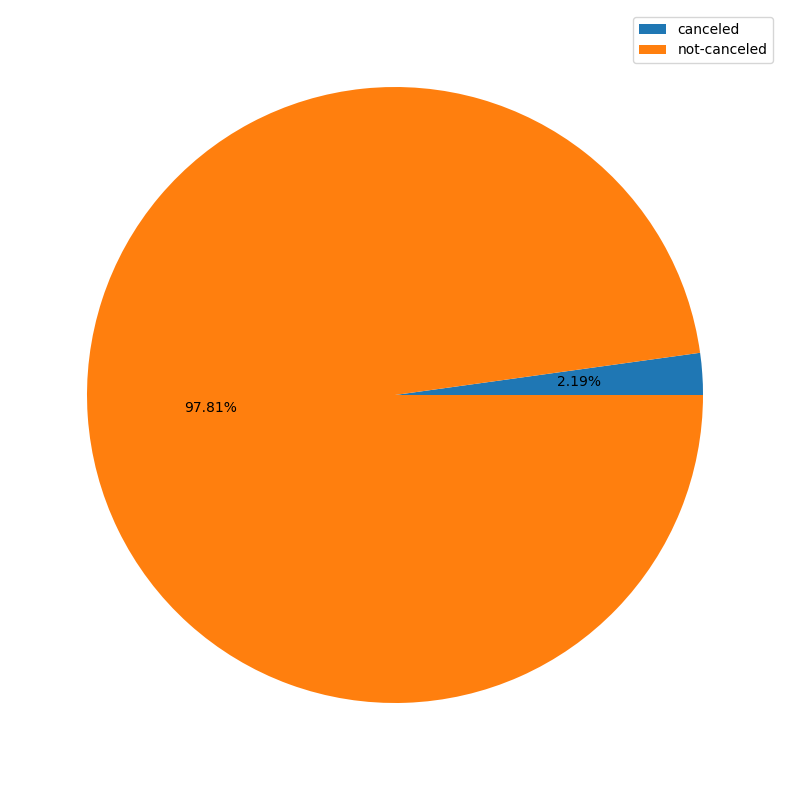

In [ ]:
df_cancellations = pd.DataFrame({
    "type" : ["canceled","not-canceled"],
    "quantity": [len(df_cancel),len(df_no_cancel)]
})
df_cancellations

plt.figure(figsize = (10,10))
plt.pie(df_cancellations["quantity"], autopct="%1.2f%%")
plt.legend(df_cancellations["type"])
plt.show()

In [ ]:
df_description = df.groupby("stockcode")["description"].value_counts().sort_values(ascending=False).reset_index()
df_description


,stockcode,description,count
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2070
1,22423,REGENCY CAKESTAND 3 TIER,1905
2,85099B,JUMBO BAG RED RETROSPOT,1662
3,84879,ASSORTED COLOUR BIRD ORNAMENT,1418
4,47566,PARTY BUNTING,1416
...,...,...,...
3911,84839,SWEETHEART KEY CABINET,1
3912,90214T,"LETTER ""T"" BLING KEY RING",1
3913,90199B,5 STRAND GLASS NECKLACE AMETHYST,1
3914,90214O,"LETTER ""O"" BLING KEY RING",1


In [ ]:

df_item_most_selled = df_no_cancel.groupby("description")["quantity"].value_counts().reset_index()
df_item_most_selled["total units"] = df_item_most_selled["quantity"] * df_item_most_selled["count"]
df_item_most_selled = df_item_most_selled.groupby("description")["total units"].sum().sort_values(ascending=False).reset_index()



In [ ]:
df_mean_spend = (df_no_cancel["quantity"]* df_no_cancel["unitprice"]).mean()
df_mean_spend

np.float64(22.394748504739596)

In [ ]:
df_no_cancel["total spend"] = df_no_cancel["quantity"] * df_no_cancel["unitprice"]
df_country = df_no_cancel.groupby("country")["total spend"].value_counts().reset_index()
df_country["total spend"] = df_country["total spend"] * df_country["count"]
df_country = df_country.groupby("country")["total spend"].sum().sort_values(ascending=False).reset_index()
df_country["porcentage"] = (df_country["total spend"] / df_country["total spend"].sum() * 100).round(2)
df_country


/tmp/ipython-input-221/3775950533.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_cancel["total spend"] = df_no_cancel["quantity"] * df_no_cancel["unitprice"]


,country,total spend,porcentage
0,United Kingdom,7308391.554,82.01
1,Netherlands,285446.340,3.20
2,EIRE,265545.900,2.98
3,Germany,228867.140,2.57
4,France,209024.050,2.35
5,Australia,138521.310,1.55
6,Spain,61577.110,0.69
7,Switzerland,56443.950,0.63
8,Belgium,41196.340,0.46
9,Sweden,38378.330,0.43


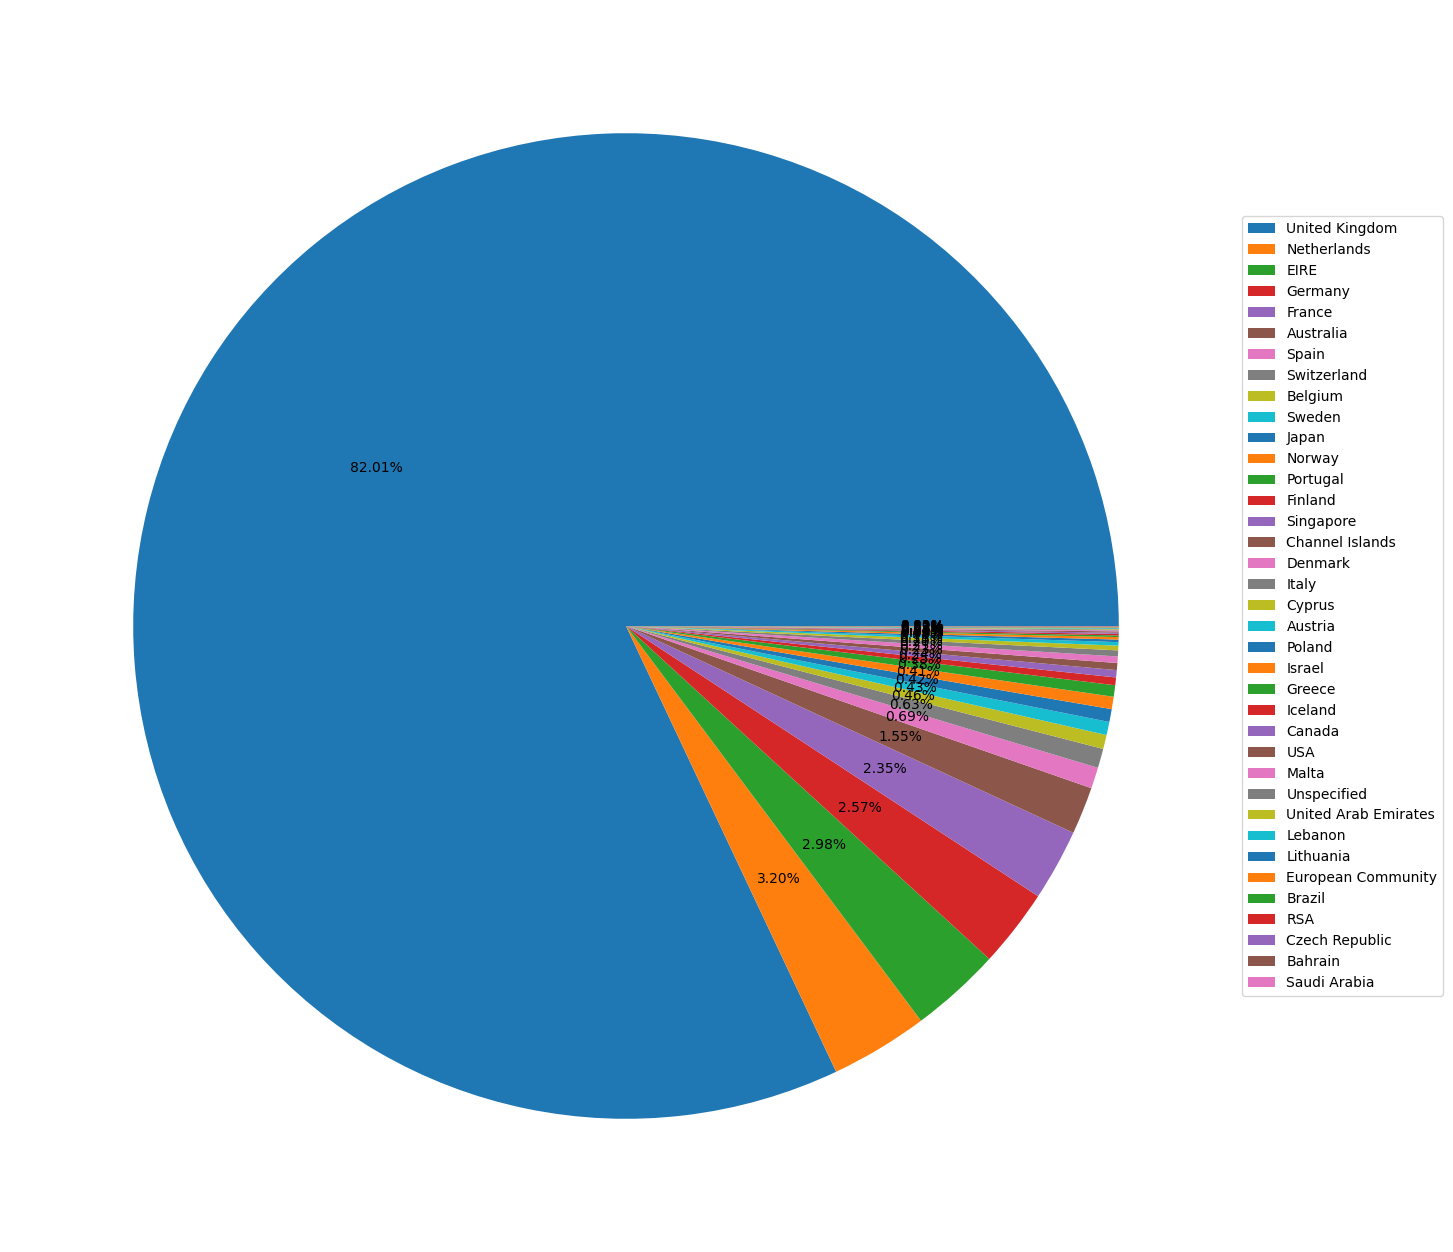

In [ ]:

plt.figure(figsize = (16,16) )
plt.pie(df_country["total spend"], autopct="%1.2f%%")
plt.legend(df_country["country"],loc=(1,0.2))
plt.show()


In [ ]:
df_no_cancel

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,total spend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [ ]:
df_customer_id = df_no_cancel.groupby("customerid")["total spend"].value_counts().reset_index()
df_customer_id["total spend"] = df_customer_id["total spend"] * df_customer_id["count"]


df_customer_id = df_customer_id.groupby("customerid")["total spend"].sum().reset_index()
df_customer_id

,customerid,total spend,count
0,12346.0,77183.6,1
1,12347.0,360.0,24
2,12347.0,272.0,16
3,12347.0,184.8,14
4,12347.0,237.6,12
...,...,...,...
142610,18287.0,45.0,1
142611,18287.0,52.2,1
142612,18287.0,53.1,1
142613,18287.0,59.4,1


In [ ]:
date = df_no_cancel["invoicedate"].max()
df_recency = df_no_cancel.groupby("customerid")["invoicedate"].max().reset_index()
df_recency["days_since_last_purchase"] = (date - df_recency["invoicedate"]).dt.days
df_recency = df_recency.sort_values(by = "days_since_last_purchase", ascending=False,).reset_index()
df_recency

,index,customerid,invoicedate,days_since_last_purchase
0,4181,18074.0,2010-12-01 09:53:00,373
1,355,12791.0,2010-12-01 11:27:00,373
2,1750,14729.0,2010-12-01 12:43:00,373
3,3104,16583.0,2010-12-01 12:03:00,373
4,1038,13747.0,2010-12-01 10:37:00,373
...,...,...,...,...
4334,471,12955.0,2011-12-08 16:29:00,0
4335,71,12433.0,2011-12-09 10:02:00,0
4336,1695,14653.0,2011-12-08 13:45:00,0
4337,61,12423.0,2011-12-09 10:10:00,0


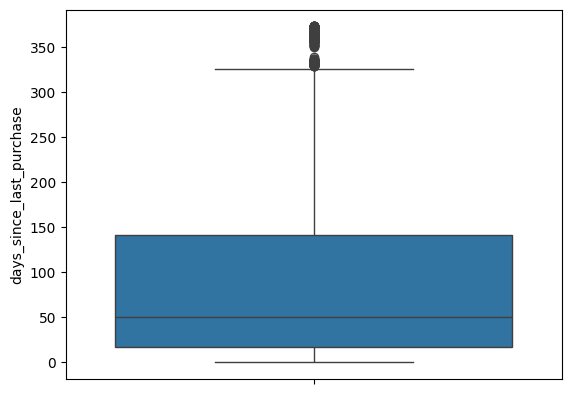

,index,customerid,invoicedate,days_since_last_purchase
0,4181,18074.0,2010-12-01 09:53:00,373
1,355,12791.0,2010-12-01 11:27:00,373
2,1750,14729.0,2010-12-01 12:43:00,373
3,3104,16583.0,2010-12-01 12:03:00,373
4,1038,13747.0,2010-12-01 10:37:00,373
...,...,...,...,...
1029,1044,13754.0,2011-07-11 11:51:00,151
1030,987,13678.0,2011-07-11 10:14:00,151
1031,1626,14552.0,2011-07-11 12:49:00,151
1032,1970,15045.0,2011-07-11 11:33:00,151


In [ ]:
sns.boxplot(df_recency["days_since_last_purchase"])
plt.show()

# df_recency[df_recency["days_since_last_purchase"]> 150]

frecuency

In [ ]:
frecuency_df_customer_id = df_no_cancel.groupby("customerid")["invoiceno"].nunique().reset_index()
frecuency_df_customer_id




,customerid,invoiceno
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1
...,...,...
4334,18280.0,1
4335,18281.0,1
4336,18282.0,2
4337,18283.0,16


In [ ]:
df_no_cancel["total_spend"] = df_no_cancel["quantity"] * df_no_cancel["unitprice"]

monetary = (
    df_no_cancel
    .groupby("customerid")["total_spend"]
    .sum()
    .reset_index(name="monetary")
)
monetary

/tmp/ipython-input-221/3865382401.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_cancel["total_spend"] = df_no_cancel["quantity"] * df_no_cancel["unitprice"]


,customerid,monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4334,18280.0,180.60
4335,18281.0,80.82
4336,18282.0,178.05
4337,18283.0,2094.88
